In [139]:
import sys
import meshio
import pyvista
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from mpi4py import MPI
from dolfinx import mesh, fem, io, plot
from dolfinx.fem import Constant, Function, form, assemble_scalar
from dolfinx.fem.petsc import LinearProblem
from basix.ufl import element
from petsc4py import PETSc

from ufl import (FacetNormal, Identity, TestFunction, TrialFunction,
                 div, dot, ds, dx, inner, lhs, nabla_grad, rhs, sym)


Info    : Reading '/home/dominik/git/dispersion_sim/meshes/2D_circular_obstacles.msh'...
Info    : 29 entities
Info    : 2621 nodes
Info    : 5244 elements
Info    : Done reading '/home/dominik/git/dispersion_sim/meshes/2D_circular_obstacles.msh'


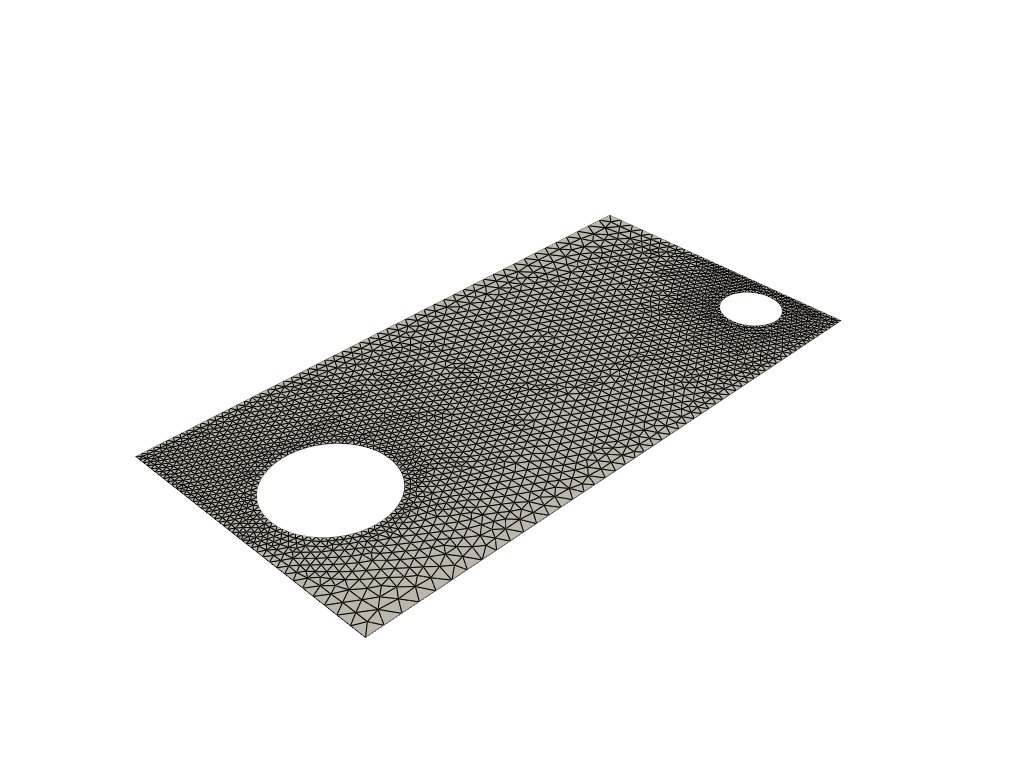

In [140]:
y_lim = 1.0
x_lim = 2.0

meshfile = Path("../meshes/2D_circular_obstacles.msh").resolve()
domain, cell_tags, facet_tags = io.gmshio.read_from_msh(meshfile, MPI.COMM_WORLD, gdim=2)
topology, cell_type, geom = plot.vtk_mesh(domain) 

grid = pyvista.UnstructuredGrid(topology, cell_type, geom)
plotter = pyvista.Plotter()
plotter.add_mesh(grid, color='lightgray', show_edges=True, edge_color='black', line_width=0.5)
plotter.show()

In [141]:
# Function spaces for v and p
V = fem.functionspace(domain, element("Lagrange", domain.basix_cell(), 2, shape=(2,)))
Q = fem.functionspace(domain, element("Lagrange", domain.basix_cell(), 1))

# Temporal parameters
t = 0.0
T = 10.0
num_steps = 1000
dt = T / num_steps
time_steps = np.arange(t, T, dt)

# Trial and test functions
u = TrialFunction(V)
v = TestFunction(V)
p = TrialFunction(Q)
q = TestFunction(Q)

# Functions
u_n = Function(V)
u_tent = Function(V)
u_new = Function(V)
p_n = Function(Q)
p_new = Function(Q)
f = Constant(domain, PETSc.ScalarType((0.0, 0.0)))

# Define strain-rate tensor
def epsilon(u):
    return sym(nabla_grad(u))

# Define stress tensor
def sigma(u, p):
    return 2 * mu * epsilon(u) - p * Identity(len(u))

u_n.name = "u_n"
U = 0.5 * (u_n + u)
n = FacetNormal(domain)
f = Constant(domain, PETSc.ScalarType((0, 0)))
k = Constant(domain, PETSc.ScalarType(dt))
mu = Constant(domain, PETSc.ScalarType(1.5e-5))
rho = Constant(domain, PETSc.ScalarType(1.2))

In [142]:
# Define the variational problem for the first step
p_n = Function(Q)
p_n.name = "p_n"
F1 = rho * dot((u - u_n) / k, v) * dx
F1 += rho * dot(dot(u_n, nabla_grad(u_n)), v) * dx
F1 += inner(sigma(U, p_n), epsilon(v)) * dx
F1 += dot(p_n * n, v) * ds - dot(mu * nabla_grad(U) * n, v) * ds
F1 -= dot(f, v) * dx
a1 = form(lhs(F1))
L1 = form(rhs(F1))

# Define variational problem for step 2
a2 = form(dot(nabla_grad(p), nabla_grad(q)) * dx)
L2 = form(dot(nabla_grad(p_n), nabla_grad(q)) * dx - (rho / k) * div(u_new) * q * dx)

# Define variational problem for step 3
a3 = form(rho * dot(u, v) * dx)
L3 = form(rho * dot(u_new, v) * dx - k * dot(nabla_grad(p_new - p_n), v) * dx)


In [143]:
def extract_tag_names(filename):
    msh = meshio.read(filename)
    return {
        data[0]: name  # tag_id: "name"
        for name, data in msh.field_data.items()
    }
tag_name_map = extract_tag_names(meshfile)
tag_name_map

{np.int64(2): 'Inflow',
 np.int64(3): 'Outflow',
 np.int64(4): 'Walls',
 np.int64(5): 'Obstacle1',
 np.int64(6): 'Obstacle2',
 np.int64(1): 'Volume'}

In [144]:
# No slip conditions
zero = Function(V)
zero.x.array[:] = 0.0

walls_tag      = next(tag for tag, name in tag_name_map.items() if name == "Walls")
obstacle1_tag  = next(tag for tag, name in tag_name_map.items() if name == "Obstacle1")
obstacle2_tag  = next(tag for tag, name in tag_name_map.items() if name == "Obstacle2")

fdim = domain.topology.dim - 1

walls_dofs = fem.locate_dofs_topological(V, fdim, facet_tags.find(walls_tag))
obs1_dofs  = fem.locate_dofs_topological(V, fdim, facet_tags.find(obstacle1_tag))
obs2_dofs  = fem.locate_dofs_topological(V, fdim, facet_tags.find(obstacle2_tag))

bc_walls = fem.dirichletbc(zero, walls_dofs)
bc_obs1  = fem.dirichletbc(zero, obs1_dofs)
bc_obs2  = fem.dirichletbc(zero, obs2_dofs)

bcs = [bc_walls, bc_obs1, bc_obs2]

inflow_tag = next(tag for tag, name in tag_name_map.items() if name == "Inflow")

fdim = domain.topology.dim - 1
inflow_facets = facet_tags.find(inflow_tag)
inflow_dofs = fem.locate_dofs_topological(V, fdim, inflow_facets)

In [145]:
# Inflow boundary
inflow_profile = Function(V)

x = V.tabulate_dof_coordinates().T
inflow_dofs_coords = x[:, inflow_dofs]

y_centered = (inflow_dofs_coords[1] - y_lim / 2.0) / (y_lim / 2.0)
u_val = 4.0 * (1 - y_centered) * y_centered

inflow_profile.x.array[:] = 0.0
inflow_profile.x.array[inflow_dofs * 2] = u_val

bc_in = fem.dirichletbc(inflow_profile, inflow_dofs)

p_out = Function(Q)
p_out.x.array[:] = 0.0

outflow_tag = next(tag for tag, name in tag_name_map.items() if name == "Outflow")
outflow_dofs = fem.locate_dofs_topological(Q, fdim, facet_tags.find(outflow_tag))

bc_out = fem.dirichletbc(p_out, outflow_dofs)

In [146]:
# Outflow
zero = Function(V)
zero.x.array[:] = 0.0

walls_tag      = next(tag for tag, name in tag_name_map.items() if name == "Walls")
obstacle1_tag  = next(tag for tag, name in tag_name_map.items() if name == "Obstacle1")
obstacle2_tag  = next(tag for tag, name in tag_name_map.items() if name == "Obstacle2")

fdim = domain.topology.dim - 1

walls_dofs = fem.locate_dofs_topological(V, fdim, facet_tags.find(walls_tag))
obs1_dofs  = fem.locate_dofs_topological(V, fdim, facet_tags.find(obstacle1_tag))
obs2_dofs  = fem.locate_dofs_topological(V, fdim, facet_tags.find(obstacle2_tag))

bc_walls = fem.dirichletbc(zero, walls_dofs)
bc_obs1  = fem.dirichletbc(zero, obs1_dofs)
bc_obs2  = fem.dirichletbc(zero, obs2_dofs)

bcs = [bc_walls, bc_obs1, bc_obs2]

inflow_tag = next(tag for tag, name in tag_name_map.items() if name == "Inflow")

fdim = domain.topology.dim - 1
inflow_facets = facet_tags.find(inflow_tag)
inflow_dofs = fem.locate_dofs_topological(V, fdim, inflow_facets)

In [147]:
# bcs summary
velocity_bcs = [bc_in, bc_walls, bc_obs1, bc_obs2]
pressure_bcs = [bc_out]

Converged after 19 iterations.
Final L2 err = 3.27e-11


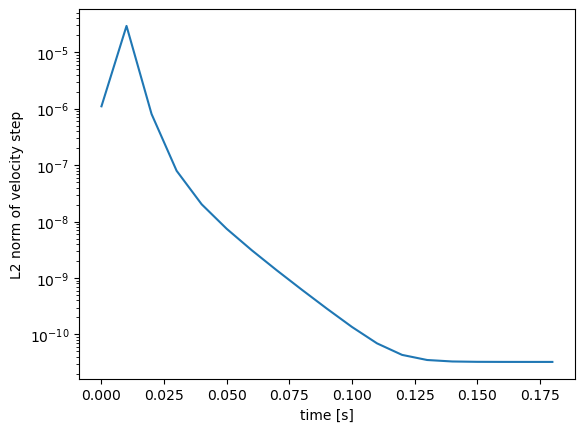

In [148]:
# Set up and solve

tentative_velocity_problem = LinearProblem(a1, L1, velocity_bcs, u_tent, 
                                           petsc_options={"ksp_type": "gmres"})
pressure_problem = LinearProblem(a2, L2, pressure_bcs, p_new)
velocity_correction_problem = LinearProblem(a3, L3, velocity_bcs, u_new)

# Error form
num_dofs = V.dofmap.index_map.size_global * V.dofmap.index_map_bs
u_diff = Function(V) 
l2_norm_squared = form(inner(u_diff, u_diff) * dx)
l2_errors = np.zeros(num_steps)
it_conv = np.inf
for idx, t_i in enumerate(time_steps):
    t = t_i
    tentative_velocity_problem.solve()
    pressure_problem.solve()
    velocity_correction_problem.solve()
    u_diff.x.array[:] = u_new.x.array - u_n.x.array
    l2_errors[idx] = np.sqrt(assemble_scalar(l2_norm_squared)) / num_dofs
    
    if t_i > time_steps[0]:
        if abs(l2_errors[idx] - l2_errors[idx - 1]) < 1e-14:
            it_conv = idx
            print(f"Converged after {idx + 1} iterations.")
            print(f"Final L2 err = {l2_errors[it_conv]:.2e}")
            
            break
    u_n.x.array[:] = u_new.x.array
    p_n.x.array[:] = p_new.x.array
    sys.stdout.flush()


if it_conv == np.inf:
    print(f"Reached max number of iterations ({num_steps}). L2 Error: {l2_errors[-1]:.2e}")

if it_conv == np.inf:
    plt.semilogy(time_steps, l2_errors)
else:
    plt.semilogy(time_steps[0:it_conv+1], l2_errors[0:it_conv+1])
plt.xlabel("time [s]")
plt.ylabel("L2 norm of velocity step")
sys.stdout.flush()


In [149]:
output_dir =  Path("./output_results").resolve()

dom_cell = domain.basix_cell()
V_u_vis = fem.functionspace(domain, element("Lagrange", dom_cell, 1, shape=(domain.topology.dim,)))
V_p_vis = fem.functionspace(domain, element("Lagrange", dom_cell, 1))

u_vis = Function(V_u_vis)
p_vis = Function(V_p_vis)

u_vis.interpolate(u_new)
p_vis.interpolate(p_new)

with io.XDMFFile(MPI.COMM_WORLD, output_dir / "velocity.xdmf", "w") as f_u:
    f_u.write_mesh(domain)
    u_vis.name = "velocity"
    f_u.write_function(u_vis, 0)

with io.XDMFFile(MPI.COMM_WORLD, output_dir / "pressure.xdmf", "w") as f_p:
    f_p.write_mesh(domain)
    p_vis.name = "pressure"
    f_p.write_function(p_vis, 0)

In [152]:
type(msh)
#type(domain)

meshio._mesh.Mesh